In [ ]:
# Create a bootstrap for all of this table. 

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from collections import defaultdict
from joblib import Parallel, delayed
import statsmodels.api as sm
from pyfixest.estimation import feols

In [40]:
out_path = "../../data/results/sat_full/"
table_out_path = "../tables/sat_final/tables/"

In [41]:
def mean_mask(s: pd.Series, mask: pd.Series) -> float:
    s2 = s[mask & s.notna()]
    return float(s2.mean()) if len(s2) else np.nan

------

### SAT Decomposition

In [42]:
df_sat_path = "../../data/results/sat_full/data_sat_scored.csv"

In [43]:
df_sat = pd.read_csv(df_sat_path, encoding="ISO-8859-1", index_col=0)
df_sat = df_sat.sort_values(["essay_id","k"]).reset_index(drop=True)

In [44]:
# FE regression
res = feols("score_high_full ~ 1 | essay_id + k", data=df_sat[df_sat['k']!=0])
print(res.summary)

fes = res.fixef()
fe_essay_map = fes["C(essay_id)"]  #
fe_k_map = fes["C(k)"]

# Map back to rows
df_sat["fe_essay"] = df_sat["essay_id"].map(fe_essay_map)
df_sat["fe_k"] = df_sat["k"].map(fe_k_map)

# Style residual (after removing essay FE only, as in your code)
df_sat["u"] = df_sat["score_high_full"] - df_sat["fe_essay"]

# Compute diff column
df_sat["diff"] = df_sat["score_high_full"] - df_sat["score_low_full"]

# Save DataFrame with FEs and residuals
df_sat.to_csv(out_path + "decomp_rows_with_fe.csv", index=False)
print(f"Saved augmented dataset - {out_path}decomp_rows_with_fe.csv")

functools.partial(<function summary at 0x1422cf880>, models=[<pyfixest.estimation.feols_.Feols object at 0x1466b0350>])
Saved augmented dataset - ../../data/results/sat_full/decomp_rows_with_fe.csv


In [45]:
def compute_decomposition_point_estimates(df_in: pd.DataFrame):
    df_ = df_in.copy()

    # --- A) total gap (k==0)
    mA = (df_["low_SES"]==0) & (df_["k"]==0) & df_["score_high_full"].notna()
    mB = (df_["low_SES"]==1) & (df_["k"]==0) & df_["score_low_full"].notna()
    tmp_vals = pd.Series(np.nan, index=df_.index)
    tmp_vals[mA] = df_.loc[mA, "score_high_full"].astype(float)
    tmp_vals[mB] = df_.loc[mB, "score_low_full"].astype(float)

    group = pd.Series(np.nan, index=df_.index)
    group[mA] = 0
    group[mB] = 1

    m0 = (group==0)
    m1 = (group==1)

    mean0 = mean_mask(tmp_vals, m0)
    mean1 = mean_mask(tmp_vals, m1)
    total_gap = mean0 - mean1

    # --- B) content gap (k==0), use essay FE
    mK0 = (df_["k"]==0)
    content_mean0 = mean_mask(df_["fe_essay"], mK0 & (df_["low_SES"]==0))
    content_mean1 = mean_mask(df_["fe_essay"], mK0 & (df_["low_SES"]==1))
    content_gap = content_mean0 - content_mean1

    # --- C) style gap via residual u = score_high_full - fe_essay
    u_mean0 = mean_mask(df_["u"], mK0 & (df_["low_SES"]==0))
    u_mean1 = mean_mask(df_["u"], mK0 & (df_["low_SES"]==1))
    style_gap = u_mean0 - u_mean1

    # --- D) others gap (your original "diff" within high-SES at k==0)
    m_last = (df_["low_SES"]==1) & (df_["k"]==0)
    sh_mean = mean_mask(df_["score_high_full"], m_last)
    sl_mean = mean_mask(df_["score_low_full"],  m_last)
    others_gap = sh_mean - sl_mean

    return {
        "total_gap": total_gap,
        "content_gap": content_gap,
        "style_gap": style_gap,
        "others_gap": others_gap,
        "share_content": content_gap/total_gap if pd.notna(total_gap) and total_gap!=0 else np.nan,
        "share_style": style_gap/total_gap   if pd.notna(total_gap) and total_gap!=0 else np.nan,
        "share_others": others_gap/total_gap  if pd.notna(total_gap) and total_gap!=0 else np.nan,
    }

point_est = compute_decomposition_point_estimates(df_sat)
point_est

{'total_gap': 0.6633067342986796,
 'content_gap': 0.4560656086433972,
 'style_gap': 0.1730503395222922,
 'others_gap': 0.03419078613298998,
 'share_content': 0.6875636640800875,
 'share_style': 0.26089037028285256,
 'share_others': 0.05154596563705963}

----

### Neutral Decomposition

In [46]:
df_neutral_path = "../../data/results/no_desc/no_desc_scored.csv"

In [114]:
df_neutral = pd.read_csv(df_neutral_path, encoding="ISO-8859-1", index_col=0)
df_neutral = df_neutral.sort_values(["essay_id", "k"]).reset_index(drop=True)

res = feols(
    "score_high_full ~ 1 | essay_id + k",
    data=df_neutral[df_neutral['k']!=0]
)

fes = res.fixef()
fe_essay_map = fes["C(essay_id)"]
fe_k_map = fes["C(k)"]
df_neutral["fe_essay"] = df_neutral["essay_id"].map(fe_essay_map)
df_neutral["fe_k"] = df_neutral["k"].map(fe_k_map)
df_neutral["u"] = df_neutral["score_high_full"] - df_neutral["fe_essay"]

df_neutral_decomp = compute_decomposition_point_estimates(df_neutral)
df_neutral_decomp



{'total_gap': 0.6572251073631734,
 'content_gap': 0.500665138567681,
 'style_gap': 0.12203150195046802,
 'others_gap': 0.034528466845023864,
 'share_content': 0.7617863848451859,
 'share_style': 0.18567687171913705,
 'share_others': 0.05253674343567632}

#### GPT Baseline

In [47]:
df_neutral = pd.read_csv(df_neutral_path, encoding="ISO-8859-1", index_col=0)
df_neutral = df_neutral.sort_values(["essay_id", "k"]).reset_index(drop=True)

In [48]:
# SES groups
mask_H = df_neutral["low_SES"] == 0   # High SES
mask_L = df_neutral["low_SES"] == 1   # Low SES

# Rewrite status
mask_orig = df_neutral["k"] == 0      # Original text
mask_neu  = df_neutral["k"] != 0      # Neutral (GPT-style) rewrite

In [49]:
# --- Under scorer S(H)
mu_H_orig = mean_mask(df_neutral["score_high_full"], mask_H & mask_orig)
mu_L_orig = mean_mask(df_neutral["score_high_full"], mask_L & mask_orig)

mu_H_neu  = mean_mask(df_neutral["score_high_full"], mask_H & mask_neu)
mu_L_neu  = mean_mask(df_neutral["score_high_full"], mask_L & mask_neu)

# --- Under scorer S(L), originals only
mu_L_orig_Lscorer = mean_mask(df_neutral["score_low_full"], mask_L & mask_orig)

means = {
    "mu_H_orig": mu_H_orig,
    "mu_L_orig": mu_L_orig,
    "mu_H_neu": mu_H_neu,
    "mu_L_neu": mu_L_neu,
    "mu_L_orig_Lscorer": mu_L_orig_Lscorer
}

means

{'mu_H_orig': 3.639631589364649,
 'mu_L_orig': 3.0169349488464996,
 'mu_H_neu': 3.894064639865456,
 'mu_L_neu': 3.3933995012977753,
 'mu_L_orig_Lscorer': 2.9824064820014757}

In [50]:
total_gap = mu_H_orig - mu_L_orig_Lscorer   # Δ_obs


content_gap = mu_H_neu - mu_L_neu

highPremium = (mu_H_orig - mu_H_neu)
lowPremium = (mu_L_orig - mu_L_neu)

style_gap = highPremium - lowPremium

scorer_gap = mu_L_orig - mu_L_orig_Lscorer

decomp = {
    "total_gap": total_gap,
    "content_gap": content_gap,
    "style_gap": style_gap,
    "scorer_gap": scorer_gap,
    "share_content": content_gap / total_gap if total_gap else np.nan,
    "share_style": style_gap / total_gap if total_gap else np.nan,
    "share_scorer": scorer_gap / total_gap if total_gap else np.nan,
    "high Premium": highPremium/total_gap, 
    "low Premium": lowPremium/total_gap
    
}

decomp

{'total_gap': 0.6572251073631734,
 'content_gap': 0.5006651385676806,
 'style_gap': 0.12203150195046897,
 'scorer_gap': 0.034528466845023864,
 'share_content': 0.7617863848451852,
 'share_style': 0.1856768717191385,
 'share_scorer': 0.05253674343567632,
 'high Premium': -0.3871322742395029,
 'low Premium': -0.5728091459586414}

In [51]:
def build_neutral_decomp_df(df_in: pd.DataFrame) -> pd.DataFrame:
    df = df_in.copy()

    # --- Identify original and neutral rows
    df_orig = df[df["k"] == 0].copy()
    df_neu  = df[df["k"] == 1].copy()

    # --- Drop grade levels 9.0 and 12.0
    df_orig = df_orig[~df_orig["grade_level"].isin([9.0, 12.0])]
    df_neu  = df_neu[df_neu["essay_id"].isin(df_orig["essay_id"])]

    # --- Keep only columns needed for merging
    keep_cols = [
        "essay_id", "low_SES", "race_white", "gender_male",
        "prompt_name", "grade_level", "cv_fold",
        "score_high_full", "score_low_full"
    ]

    df_orig = df_orig[keep_cols].rename(columns={
        "score_high_full": "score_high_orig",
        "score_low_full":  "score_low_orig"
    })

    df_neu = df_neu[[
        "essay_id", "score_high_full"
    ]].rename(columns={
        "score_high_full": "score_high_neu"
    })

    # --- Merge original + neutral
    out = df_orig.merge(df_neu, on="essay_id", how="inner")

    # --- Row-level neutral decomposition
    out["content_neu"] = out["score_high_neu"]
    out["style_premium"] = out["score_high_orig"] - out["score_high_neu"]

    # --- Scorer difference (original)
    out["diff_high_low_orig"] = (
        out["score_high_orig"] - out["score_low_orig"]
    )

    # --- Restore k column meaningfully
    out["k"] = 0

    return out

In [52]:
df_neutral_decomp = build_neutral_decomp_df(df_neutral)
df_neutral_decomp.head()

,essay_id,low_SES,race_white,gender_male,prompt_name,grade_level,cv_fold,score_high_orig,score_low_orig,score_high_neu,content_neu,style_premium,diff_high_low_orig,k
0,00009d59-fa66-4a21-ab82-c9585bafbb0f,True,False,True,Driverless cars,10.0,4,3.637174,3.610687,4.192033,4.192033,-0.554859,0.026486,0
1,0003b509-e82c-4905-b76b-b4145f453b36,False,True,False,Cell phones at school,8.0,2,2.582573,2.607545,2.758356,2.758356,-0.175784,-0.024973,0
2,00088121-1a97-4d80-ba45-44c51d828ff2,True,False,True,Community service,8.0,5,3.078734,2.636030,3.080454,3.080454,-0.001720,0.442703,0
3,00092bf2-6089-44b7-9429-d03ae74aa24a,False,True,False,Grades for extracurricular activities,8.0,5,2.896804,2.922007,3.153955,3.153955,-0.257151,-0.025203,0
4,000a79a3-0028-4c9b-8358-45465fd690e4,False,False,False,Community service,8.0,4,4.755594,4.770242,5.044900,5.044900,-0.289306,-0.014648,0


----

### Robustness: Score Range Restriction

As a robustness check, we re-estimate the decomposition after restricting the sample to essays whose original (unrewritten) scores lie in the interior of the scoring scale, specifically scores 2 through 5. This restriction excludes boundary cases where essays cannot be meaningfully rewritten upward or downward, ensuring that all essays in the sample admit comparable stylistic perturbations.

in addition we restrict the rewrites to rewrites that adjust the score one up or one down. For example, if the score is 2 we allow for rewrites 1,2,3

In [106]:
df_sat = pd.read_csv(df_sat_path, encoding="ISO-8859-1", index_col=0)
df_sat = df_sat.sort_values(["essay_id", "k"]).reset_index(drop=True)

df_sat = df_sat[(df_sat['true_score']<=5) & (df_sat['true_score']>=2)  ]
mask = (np.abs(df_sat['k'] - df_sat['true_score'])<=1) | (df_sat['k']==0)
df_sat = df_sat[mask]

res = feols(
    "score_high_full ~ 1 | essay_id + k",
    data=df_sat[df_sat['k']!=0]
)

fes = res.fixef()
fe_essay_map = fes["C(essay_id)"]
fe_k_map = fes["C(k)"]
df_sat["fe_essay"] = df_sat["essay_id"].map(fe_essay_map)
df_sat["fe_k"] = df_sat["k"].map(fe_k_map)
df_sat["u"] = df_sat["score_high_full"] - df_sat["fe_essay"]


In [105]:
score25_res = compute_decomposition_point_estimates(df_sat)
score25_res

{'total_gap': 0.546797050925167,
 'content_gap': 0.37936563484867936,
 'style_gap': 0.13522297481742684,
 'others_gap': 0.03220844125906153,
 'share_content': 0.6937960513993303,
 'share_style': 0.24730011727135864,
 'share_others': 0.05890383132931249}

In [107]:
df_sat = pd.read_csv(df_sat_path, encoding="ISO-8859-1", index_col=0)
df_sat = df_sat.sort_values(["essay_id", "k"]).reset_index(drop=True)

mask = df_sat['k'].isin([0,1,6,2,5])
df_sat = df_sat[mask]

res = feols(
    "score_high_full ~ 1 | essay_id + k",
    data=df_sat[df_sat['k']!=0]
)

fes = res.fixef()
fe_essay_map = fes["C(essay_id)"]
fe_k_map = fes["C(k)"]
df_sat["fe_essay"] = df_sat["essay_id"].map(fe_essay_map)
df_sat["fe_k"] = df_sat["k"].map(fe_k_map)
df_sat["u"] = df_sat["score_high_full"] - df_sat["fe_essay"]


In [108]:
score1625_res = compute_decomposition_point_estimates(df_sat)
score1625_res

{'total_gap': 0.6633067342986796,
 'content_gap': 0.44207630856667857,
 'style_gap': 0.18703963959901115,
 'others_gap': 0.03419078613298998,
 'share_content': 0.6664734212808648,
 'share_style': 0.28198061308207567,
 'share_others': 0.05154596563705963}

----

### Robustness: Dropping k=1 Rewrites

As an additional robustness check, we replicate the decomposition after removing all rewrites with k=1. This tests whether results are sensitive to the inclusion of the lowest-intensity rewrite level. The fixed-effects specification and all gap calculations are unchanged.

In [59]:
df_sat = pd.read_csv(df_sat_path, encoding="ISO-8859-1", index_col=0)
df_sat = df_sat.sort_values(["essay_id", "k"]).reset_index(drop=True)

# --- Robustness: drop k=1 rewrites
df_sat_dropk1 = df_sat[df_sat["k"] != 1].copy()

# FE regression (same spec)
res_dropk1 = feols("score_high_full ~ 1 | essay_id + k", data=df_sat_dropk1[df_sat_dropk1['k']!=0])

# Fixed effects
fes = res_dropk1.fixef()
fe_essay_map = fes["C(essay_id)"]
fe_k_map = fes["C(k)"]

# Map back
df_sat_dropk1["fe_essay"] = df_sat_dropk1["essay_id"].map(fe_essay_map)
df_sat_dropk1["fe_k"] = df_sat_dropk1["k"].map(fe_k_map)

# Residual + diff (same definitions)
df_sat_dropk1["u"] = df_sat_dropk1["score_high_full"] - df_sat_dropk1["fe_essay"]
df_sat_dropk1["diff"] = df_sat_dropk1["score_high_full"] - df_sat_dropk1["score_low_full"]

# Decomposition (same function)
point_est_dropk1 = compute_decomposition_point_estimates(df_sat_dropk1)
point_est_dropk1

{'total_gap': 0.6633067342986796,
 'content_gap': 0.47209094699842913,
 'style_gap': 0.1570250011672601,
 'others_gap': 0.03419078613298998,
 'share_content': 0.7117234344041077,
 'share_style': 0.23673059995883217,
 'share_others': 0.05154596563705963}

----

In [60]:
decomps

{'SAT (baseline)': {'content': 0.6875636640800875,
  'style': 0.26089037028285256,
  'residual': 0.05154596563705963,
  'total_gap': 0.6633067342986796},
 'Score 2–5 only': {'content': 0.6782642578598153,
  'style': 0.2628319108108733,
  'residual': 0.05890383132931249,
  'total_gap': 0.546797050925167},
 'Drop SAT 1': {'content': 0.7117234344041077,
  'style': 0.23673059995883217,
  'residual': 0.05154596563705963,
  'total_gap': 0.6633067342986796},
 'Baseline GPT': {'content': 0.804027364193059,
  'style': 0.19597263580694096,
  'residual': 0.05544990063908571,
  'total_gap': 0.6226966405181495}}

In [116]:
# ---- Decomposition results (plug in yours)
decomps = {
    "SAT (baseline)": {
        "content": point_est["share_content"],
        "style": point_est["share_style"],
        "residual": point_est["share_others"],
        "total_gap": point_est["total_gap"],
    },
    "Score 2–5 only": {
        "content": score25_res["share_content"],
        "style": score25_res["share_style"],
        "residual": score25_res["share_others"],
        "total_gap": score25_res["total_gap"],
    },
    "Rewrites 1,6,2,5 only": {
        "content": score1625_res["share_content"],
        "style": score1625_res["share_style"],
        "residual": score1625_res["share_others"],
        "total_gap": score1625_res["total_gap"],
    },
    "Drop SAT 1": {
        "content": point_est_dropk1["share_content"],
        "style": point_est_dropk1["share_style"],
        "residual": point_est_dropk1["share_others"],
        "total_gap": point_est_dropk1["total_gap"],
    },
    "Baseline GPT": {
        "content": df_neutral_decomp["share_content"],
        "style": df_neutral_decomp["share_style"],
        "residual": df_neutral_decomp["share_others"],
        "total_gap": df_neutral_decomp["total_gap"],
    },
}



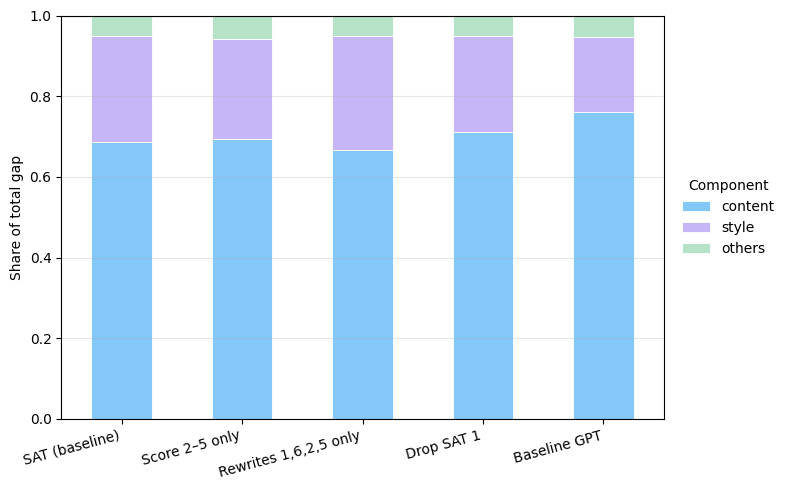

In [117]:
# ---- Build plotting DataFrame
plot_df = (
    pd.DataFrame(decomps)
      .T[["content", "style", "residual"]]
      .rename(columns={"residual": "others"})
)

COMP_ORDER  = ["content", "style", "others"]
COMP_COLORS = {"content": "#84C7F9", "style": "#C7B6F7", "others": "#B6E3C7"}

ax = plot_df[COMP_ORDER].plot(
    kind="bar",
    stacked=True,
    color=[COMP_COLORS[c] for c in COMP_ORDER],
    edgecolor="white",
    linewidth=0.6,
    figsize=(8, 5),
)

ax.set_ylabel("Share of total gap")
ax.set_xlabel("")
ax.set_ylim(0, 1)
ax.axhline(1, color="gray", lw=0.8, linestyle="--")
plt.xticks(rotation=15, ha="right")

ax.legend(
    title="Component",
    loc="center left",
    bbox_to_anchor=(1.01, 0.5),
    frameon=False
)

ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


In [118]:
decomps

{'SAT (baseline)': {'content': 0.6875636640800875,
  'style': 0.26089037028285256,
  'residual': 0.05154596563705963,
  'total_gap': 0.6633067342986796},
 'Score 2–5 only': {'content': 0.6937960513993303,
  'style': 0.24730011727135864,
  'residual': 0.05890383132931249,
  'total_gap': 0.546797050925167},
 'Rewrites 1,6,2,5 only': {'content': 0.6664734212808648,
  'style': 0.28198061308207567,
  'residual': 0.05154596563705963,
  'total_gap': 0.6633067342986796},
 'Drop SAT 1': {'content': 0.7117234344041077,
  'style': 0.23673059995883217,
  'residual': 0.05154596563705963,
  'total_gap': 0.6633067342986796},
 'Baseline GPT': {'content': 0.7617863848451859,
  'style': 0.18567687171913705,
  'residual': 0.05253674343567632,
  'total_gap': 0.6572251073631734}}